# Accessors

To extend `xarray.DataArray` and  `xarray.Dataset`
xradar aims to provide accessors which downstream libraries can hook into.

Those accessors are yet to be defined. For starters we could implement purpose-based
accessors (like `.vis`, `.kdp` or `.trafo`) on `xarray.DataArray` level.

To not have to import downstream packages a similar approach to xarray.backends using
`importlib.metadata.entry_points` could be facilitated.

In this notebook the creation of such an accessor is showcased.

In [1]:
import numpy as np
import xarray as xr
from open_radar_data import DATASETS

import xradar as xd

## Import Data

Fetch data from [open-radar-data](https://github.com/openradar/open-radar-data) repository.

In [2]:
filename = DATASETS.fetch("71_20181220_060628.pvol.h5")

### Open data

In [3]:
ds = xr.open_dataset(filename, group="sweep_0", engine="odim")
display(ds.DBZH.values)

C:\Users\egoud\.venvs\wradlib\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'radolan' loading failed:
module 'wradlib.georef.raster' has no attribute 'read_gdal_values'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


array([[ nan,  0. , 13. , ...,  nan,  nan,  nan],
       [ nan,  1.5, 13.5, ...,  nan,  nan,  nan],
       [ nan,  1.5, 11.5, ...,  nan,  nan,  nan],
       ...,
       [ nan,  1.5, 11.5, ...,  nan,  nan,  nan],
       [ nan,  1.5,  6. , ...,  nan,  nan,  nan],
       [ nan,  6. , 12.5, ...,  nan,  nan,  nan]], shape=(360, 1200))

### Plot DBZH

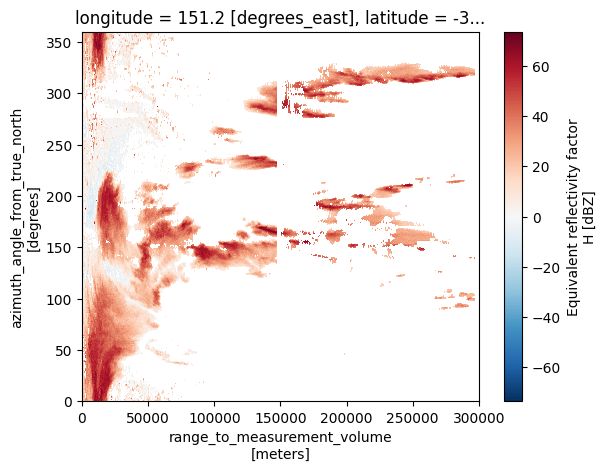

In [4]:
ds.DBZH.plot()

## Define two example functions

Functions copied verbatim from wradlib.

In [5]:
def _decibel(x):
    """Calculates the decibel representation of the input values

    :math:`dBZ=10 \\cdot \\log_{10} z`

    Parameters
    ----------
    x : float or :class:`numpy:numpy.ndarray`
        (must not be <= 0.)

    Examples
    --------
    >>> from wradlib.trafo import decibel
    >>> print(decibel(100.))
    20.0
    """
    return 10.0 * np.log10(x)


def _idecibel(x):
    """Calculates the inverse of input decibel values

    :math:`z=10^{x \\over 10}`

    Parameters
    ----------
    x : float or :class:`numpy:numpy.ndarray`

    Examples
    --------
    >>> from wradlib.trafo import idecibel
    >>> print(idecibel(10.))
    10.0

    """
    return 10.0 ** (x / 10.0)

## Function dictionaries

To show the import of the functions, we put them in different dictionaries as we would get them via `entry_points`. 

This is what the downstream libraries would have to provide.

In [6]:
package_1_func = {"trafo": {"decibel": _decibel}}
package_2_func = {"trafo": {"idecibel": _idecibel}}

## xradar internal functionality

This is how xradar would need to treat that input data.

In [7]:
downstream_functions = [package_1_func, package_2_func]
xradar_accessors = ["trafo"]

In [8]:
package_functions = {}
for accessor in xradar_accessors:
    package_functions[accessor] = {}
    for dfuncs in downstream_functions:
        package_functions[accessor].update(dfuncs[accessor])
print(package_functions)

{'trafo': {'decibel': <function _decibel at 0x000001D319ACCFE0>, 'idecibel': <function _idecibel at 0x000001D319ACD080>}}


## Create and register accessor

We bundle the different steps into one function, ``create_xradar_dataarray_accessor``.

In [9]:
for accessor in xradar_accessors:
    xd.accessors.create_xradar_dataarray_accessor(accessor, package_functions[accessor])

## Convert DBZH to linear and plot

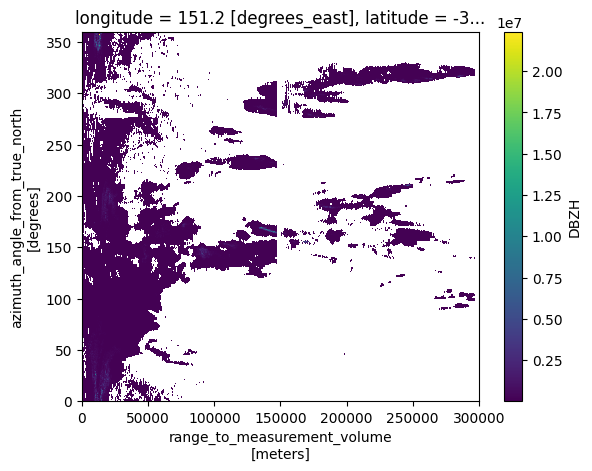

In [10]:
z = ds.DBZH.trafo.idecibel()
z.plot()

## Convert z to decibel and plot()

In [11]:
dbz = z.trafo.decibel()
display(dbz)

<xarray.DataArray 'DBZH' (azimuth: 360, range: 1200)> Size: 3MB
array([[ nan,  0. , 13. , ...,  nan,  nan,  nan],
       [ nan,  1.5, 13.5, ...,  nan,  nan,  nan],
       [ nan,  1.5, 11.5, ...,  nan,  nan,  nan],
       ...,
       [ nan,  1.5, 11.5, ...,  nan,  nan,  nan],
       [ nan,  1.5,  6. , ...,  nan,  nan,  nan],
       [ nan,  6. , 12.5, ...,  nan,  nan,  nan]], shape=(360, 1200))
Coordinates:
  * azimuth    (azimuth) float32 1kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
    elevation  (azimuth) float64 3kB ...
    time       (azimuth) datetime64[ns] 3kB ...
  * range      (range) float32 5kB 125.0 375.0 625.0 ... 2.996e+05 2.999e+05
    longitude  float64 8B ...
    latitude   float64 8B ...
    altitude   float64 8B ...

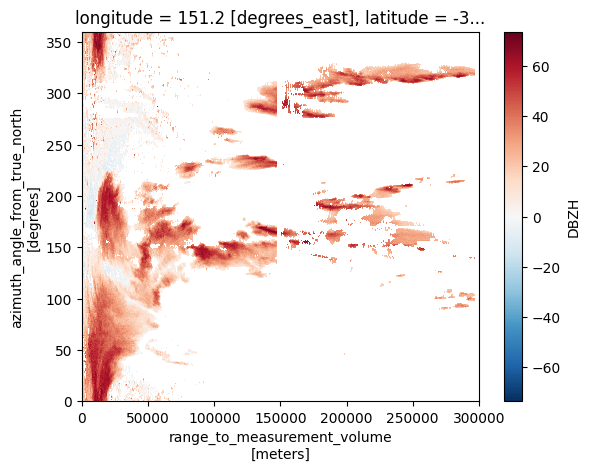

In [12]:
dbz.plot()